# ===<u>**SAE 2-06 : Analyse de données, Reporting et Data-visualisation**</u> === #
-*Yassine HAMMAMI* *Bilal BOULAHYAN*  
*BUT Science des données  
<u>2024-2025*</u>

## Rapport de l'étude cinématographique

## <u>**Contexte**</u>

Au cours des dernières années, le secteur du cinéma en France a été profondément transformé.  

Entre la <u>**crise sanitaire de 2020**</u>, <u>**l’essor des plateformes de streaming**</u>, ou encore <u>**l’impact économique de l’inflation**</u>, la fréquentation des salles a connu d’importantes fluctuations. 

Cela soulève des questions sur la capacité des cinémas à rester attractifs face à la transformation des pratiques de consommation culturelle.


## <u>**Données**</u>

Cette analyse s’appuie principalement sur des jeux de données publiques mis à disposition par le **Ministère de la Culture** et le **Centre National du Cinéma et de l'image animée (CNC)** :

1. **Données principales** :  
   - Jeu de données *« établissements-cinematographiques »*, disponible sur la plateforme open data du gouvernement français ([data.culture.gouv.fr](https://data.culture.gouv.fr/explore/dataset/etablissements-cinematographiques/)).
   - Ce fichier fournit chaque année une description détaillée des cinémas actifs en France : localisation, nombre d’écrans, équipements, programmation et fréquentation (données disponibles de 2018 à 2022).

2. **Données complémentaires** :  
   - La base **BASILIC** (*Base des Lieux et des Équipements Culturels*), également fournie par le Ministère de la Culture. Elle permet d’identifier et de localiser les équipements culturels (dont les cinémas), pour enrichir l’analyse géographique.
   - Lien : [Base BASILIC](https://data.culture.gouv.fr/explore/dataset/base-des-lieux-et-des-equipements-culturels/)

3. **Autres ressources CNC** :  
   - Rapports et statistiques annuelles publiés par le CNC, utilisés pour la comparaison et la création de tableaux statistiques.

Ces jeux de données permettent de couvrir l’évolution du parc et de la fréquentation des cinémas entre **2017 et 2024**, en incluant les effets de la crise sanitaire et les évolutions récentes.

## <u>**Objectifs**</u>

L’étude vise notamment à observer l’impact de la crise sanitaire sur la fréquentation des salles, en comparant les données **avant**, **pendant**, et **après** 2020.

Plus largement, elle a pour ambition de :
1. **Dresser un panorama du parc cinématographique français**, à l’échelle nationale, régionale, départementale et locale.
2. **Analyser les tendances de fréquentation sur la période 2017–2024**, afin de mieux comprendre l’évolution des usages.
3. **Développer des visualisations claires et interactives** pour faire ressortir les indicateurs clés (fréquentation, équipement, localisation…).

## <u>**Démarche**</u>

Ce projet suit une méthodologie structurée en plusieurs étapes, permettant de passer des données brutes à une analyse complète, illustrée par des visualisations et des indicateurs.

## <u>1 . Importation des modules</u>
Nous commençons par importer les bibliothèques nécessaires (`pandas`, `numpy`, `seaborn`) ainsi que le module personnel contenant les fonctions développées par nos soins pour cette SAE.

## <u>2 . Introduction de la SAE</u>
Une présentation du contexte, des objectifs et des sources de données permet de poser les bases de l’analyse.

## <u>3 . Traitement des données</u>
Cette partie explique ce qu’il est possible de faire à chaque étape :
- **Chargement** des jeux de données,
- **Préparation des données & traitement des anomalies** des données,
- **Calculs d'indicateurs statistiques** (moyenne, max, min, mediane..),
- **Extraction** des colonnes pertinentes pour l’analyse,
- **Export** des bases nettoyées et des tableaux créés grâce au module python cinema.

Des exemples concrets sont fournis pour illustrer ces actions.

## <u>4 . Calculs statistiques avec Python</u>
Nous décrivons ici différentes analyses possibles, puis nous choisissons des exemples pertinents à exécuter :
- Moyenne des entrées par année (2019, 2020, 2021),
- Répartition géographique,
- Évolution annuelle par type de salle, écrans, fauteuils...

## <u>5 . Travail multi-annuelle</u>
Nous regroupons les données sur plusieurs années (de 2017 à 2022, voire jusqu’en 2024) afin de :
- Suivre l’évolution de la fréquentation,
- Calculer des indicateurs transversaux.

## <u>Partie 2 : Visualisation avec Pandas</u>
Nous utilisons les fonctions statistiques intégrées à `pandas` pour obtenir des indicateurs descriptifs, visualiser un extrait des données, et présenter des statistiques globales par des graphgiques pertinants.


## <u>Conclusion du notebook</u>
Un résumé est proposé en fin de notebook pour synthétiser les observations majeures.

## <u>Conclusion générale de la SAE</u>
Une dernière partie met en perspective l’ensemble du projet : compétences mobilisées, apports de l’étude, limites, et pistes d’amélioration ou de prolongement.

## Partie 1 : <u><b>Traitement des données cartographique</u></b>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import module_cinema as mc

### <u>**Importation des fichiers**</u>

**Ici, nous chargeons les fichiers `Données cartographie` pour les années <u>2019</u>, <u>2020</u>et <u>2021</u>dans leur entièreté.**

In [3]:
data=mc.charger_fichier_csv(1,fichier1="../data/Données Cartographie 2019.csv",fichier2="../data/Données cartographie 2020.csv",fichier3="../data/Données cartographie 2021.csv")
data_carto2019 = data[0]
data_carto2020 = data[1]
data_carto2021 = data[2]

for ligne in data_carto2019:
    ligne['annee'] = 2019
for ligne in data_carto2020:
    ligne['annee'] = 2020
for ligne in data_carto2021:
    ligne['annee'] = 2021

**Nous fusionnonsles fichiers 2020, 2021 pour pouvoir les comparer par la suite.**

In [4]:
data_fusion_20_21 = data_carto2020 + data_carto2021
mc.exportation_fich_dictionnaire("donnee_fusionner.csv", data_fusion_20_21)

### <u>**Description et aperçu**</u>

Ici nous utilisons notre `module cinéma` pour la description des données fusionnées (2020 et 2021) avec comme variables choisies *"entrées"* , *"écrans"* et *"fauteuil"*.  
Voici un **aperçu**

In [5]:
tcd = mc.tableau_stat(data_fusion_20_21, "annee", "entrées")
print("-------------Description-------------")
tcd_region = mc.tableau_stat(data_fusion_20_21, "région administrative", "entrées", "écrans", "fauteuils")


largeurs = [0] * len(tcd_region[0])
for ligne in tcd_region:
    for i, val in enumerate(ligne):
        largeurs[i] = max(largeurs[i], len(str(val)))
header = " | ".join(str(val).ljust(largeurs[i]) for i, val in enumerate(tcd_region[0]))
print(header)
print("-" * (sum(largeurs) + 3 * (len(largeurs) - 1)))
for ligne in tcd_region[1:]:
    print(" | ".join(str(val).ljust(largeurs[i]) for i, val in enumerate(ligne)))


-------------Description-------------
région administrative      | entrées    | écrans | fauteuils
------------------------------------------------------------
AUVERGNE / RHONE-ALPES     | 18938302.0 | 1683.0 | 300111.0 
BOURGOGNE / FRANCHE-COMTE  | 5553731.0  | 552.0  | 96155.0  
BRETAGNE                   | 8065802.0  | 653.0  | 120465.0 
CENTRE-VAL DE LOIRE        | 5126007.0  | 416.0  | 82244.0  
CORSE                      | 526749.0   | 61.0   | 12819.0  
GRAND EST                  | 11105723.0 | 931.0  | 180702.0 
HAUTS DE FRANCE            | 11963238.0 | 894.0  | 174594.0 
ILE-DE-FRANCE              | 41264812.0 | 2348.0 | 458323.0 
NORMANDIE                  | 7102378.0  | 582.0  | 119088.0 
NOUVELLE AQUITAINE         | 13765713.0 | 1327.0 | 236733.0 
OCCITANIE                  | 12886621.0 | 1122.0 | 197029.0 
PAYS DE LA LOIRE           | 9302761.0  | 687.0  | 128322.0 
PROVENCE-ALPES-COTE D'AZUR | 12740824.0 | 1064.0 | 178478.0 


In [18]:
stats = mc.statistique(data_fusion_20_21, "entrées", "écrans", "fauteuils")

for categorie, valeurs in stats.items():
    print(f"{categorie} :")
    for nom_stat, valeur in valeurs.items():
        print(f"  {nom_stat} : {round(valeur, 2)}")
    print()

entrées :
  Somme : 158342661.0
  Nombre de valeurs : 4069
  Minimum : 0.0
  Maximum : 1408789.0
  Moyenne : 38914.39
  Mediane : 10108.0
  Variance : 5981355984.37
  Ecart-type : 77339.23

écrans :
  Somme : 12320.0
  Nombre de valeurs : 4069
  Minimum : 1.0
  Maximum : 27.0
  Moyenne : 3.03
  Mediane : 1.0
  Variance : 12.51
  Ecart-type : 3.54

fauteuils :
  Somme : 2285063.0
  Nombre de valeurs : 4069
  Minimum : 0.0
  Maximum : 7358.0
  Moyenne : 561.58
  Mediane : 288.0
  Variance : 509012.91
  Ecart-type : 713.45



### <u>Tableaux statistiques</u>

Création de deux `tableaux statistiques`, illustrant le **matériel** et les **types de films** par <u>département</u> et <u>région</u>.

In [17]:
#filtrage des données
data2021_filtre_region=mc.filtrer_donnees(data_carto2021,"région administrative",f1="HAUTS DE FRANCE",f2="ILE-DE-FRANCE",f3="Rhône-Alpes")
data2021_filtre_dep=mc.filtrer_donnees(data_carto2021,"DEP",f1="59",f2="62",f3="93")
#création et export des données
tab1=mc.tableau_stat(data2021_filtre_region,"région administrative", "écrans", "fauteuils", "séances" )
mc.exporter_liste("tableau_stat.csv",tab1)

tab2=mc.tableau_stat(data2021_filtre_dep,"DEP","nombre de films programmés","nombre de films inédits","nombre de films en semaine 1")
mc.exporter_liste("tableau_stat2.csv",tab2)


Tableau 1 :

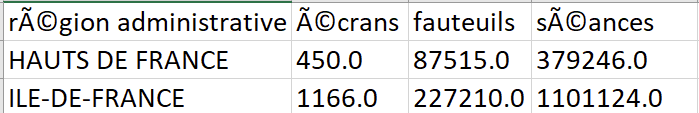

Tableau 2 :

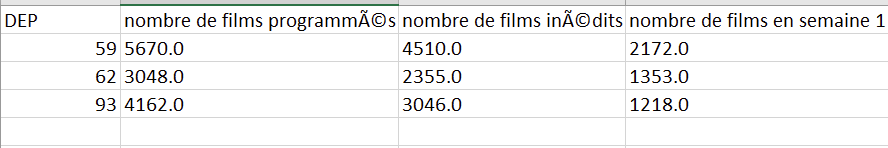


### <u>**Calculs statistiques avec Python**</u>

Nous fusionnons les données pour pouvoir rendre la description plus visible

In [8]:
data_tout = mc.fusionner_donnee(
    d2020=data_carto2020,
    d2021=data_carto2021
)
mc.describe_stat(data_tout, "entrées", "écrans", "fauteuils")

--------------------------------------------------
Description de la variable entrées:
Nombre de valeurs: 4069
Minimum: 0.0
Maximum: 1408789.0
Moyenne: 38914.39198820349
Mediane: 10108.0
Variance: 5981355984.37261
Ecart-type: 77339.2266858973
q1: 4155.0
q3: 34257.5
Mode: 4077.0
Nombre de valeurs nulles ou manquantes: 0
--------------------------------------------------
Description de la variable écrans:
Nombre de valeurs: 4069
Minimum: 1.0
Maximum: 27.0
Moyenne: 3.027770951093635
Mediane: 1.0
Variance: 12.510782173679061
Ecart-type: 3.5370584068797988
q1: 1.0
q3: 3.0
Mode: 1.0
Nombre de valeurs nulles ou manquantes: 0
--------------------------------------------------
Description de la variable fauteuils:
Nombre de valeurs: 4069
Minimum: 0.0
Maximum: 7358.0
Moyenne: 561.5785205210125
Mediane: 288.0
Variance: 509012.9144942708
Ecart-type: 713.4514100443497
q1: 188.0
q3: 551.0
Mode: 200.0
Nombre de valeurs nulles ou manquantes: 0


## Partie 2 : <u><b>Visualisation avec Pandas</u></b>

### 1 - <u>Importation des fichiers</u>

Importation des donnée des 4 années "2018" , "2019", "2020", "2021"

In [9]:
data2018 = pd.read_csv("../data/Données Cartographie 2018.csv", sep=";")
data2018['année'] = 2018

data2019 = pd.read_csv('../data/Données Cartographie 2019.csv', sep=";")
data2019['année'] = 2019

data2020 = pd.read_csv("../data/Données Cartographie 2020.csv", sep=";")
data2020['année'] = 2020

data2021 = pd.read_csv("../data/Données Cartographie 2021.csv", sep=";")
data2021['année'] = 2021

### 2 - <u>Visualisation des données</u>

#### 2.1 - Année <u> 2019</u>

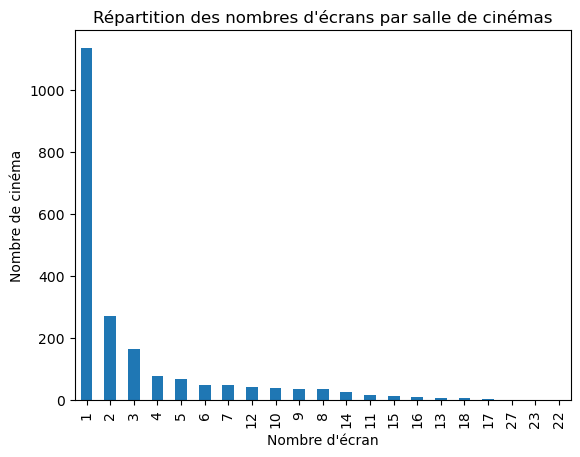

In [10]:
data2019["écrans"].value_counts().plot.bar()
plt.title("Répartition des nombres d'écrans par salle de cinémas")       
plt.xlabel("Nombre d'écran")
plt.ylabel("Nombre de cinéma")   
plt.show()

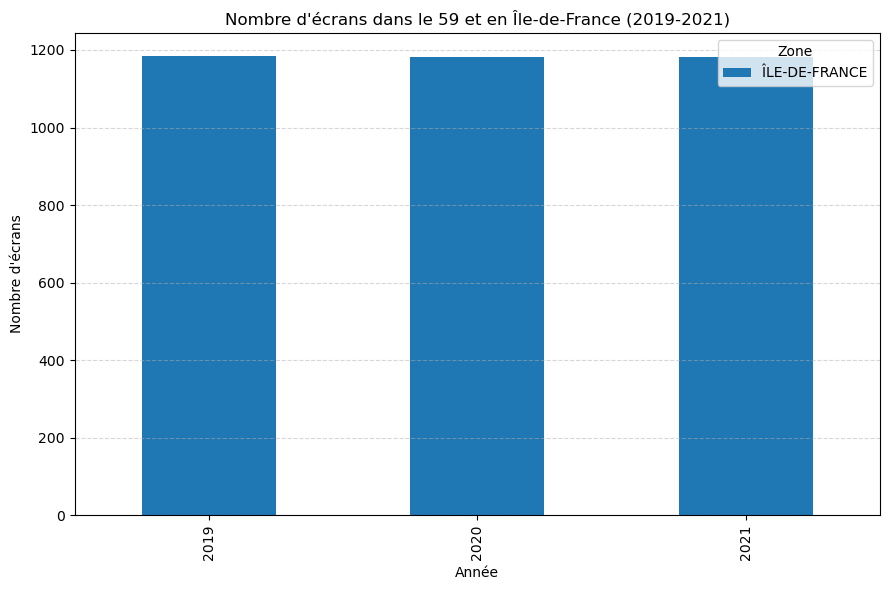

In [11]:
# Concaténation des 3 années
df_total = pd.concat([data2019, data2020, data2021])

# Filtrage sur le département 59 et la région ÎLE-DE-FRANCE
df_filtre = df_total[(df_total['DEP'] == 59) | (df_total['région administrative'].str.strip() == 'ILE-DE-FRANCE')].copy()

# Création de la colonne 'zone'
df_filtre.loc[df_filtre['DEP'] == 59, 'zone'] = 'Département 59'
df_filtre.loc[df_filtre['région administrative'].str.strip() == 'ILE-DE-FRANCE', 'zone'] = 'ÎLE-DE-FRANCE'

# Regroupement et somme des écrans
ecrans_par_annee = df_filtre.groupby(['année', 'zone'])['écrans'].sum().unstack()

# Affichage du graphique
ecrans_par_annee.plot(kind='bar', figsize=(9, 6))
plt.title("Nombre d'écrans dans le 59 et en Île-de-France (2019-2021)")
plt.xlabel("Année")
plt.ylabel("Nombre d'écrans")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Zone")
plt.tight_layout()
plt.show()

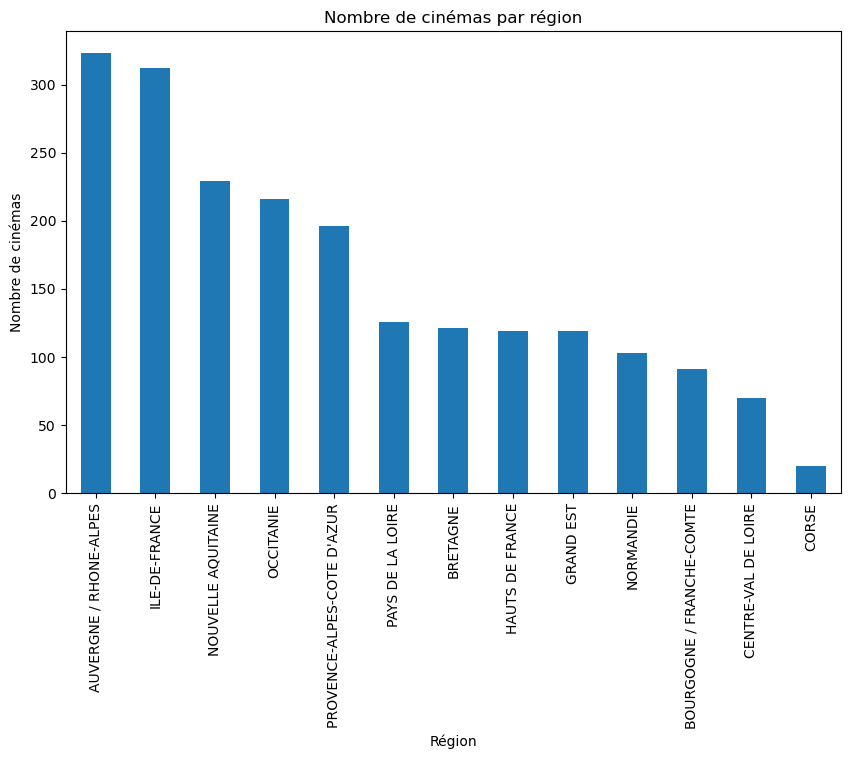

In [12]:
region_counts = data2019["région administrative"].value_counts()


region_counts.plot.bar(figsize=(10, 6))
plt.title("Nombre de cinémas par région")
plt.xlabel("Région")
plt.ylabel("Nombre de cinémas")
plt.show()

**On perçoit dans ce graphique illustrant le nombre de cinémas par région, près de <u>300</u> de cinémas en "*Auvergne / Rhone-Alpes*" ainsi qu'en "*Ile-De-France***"


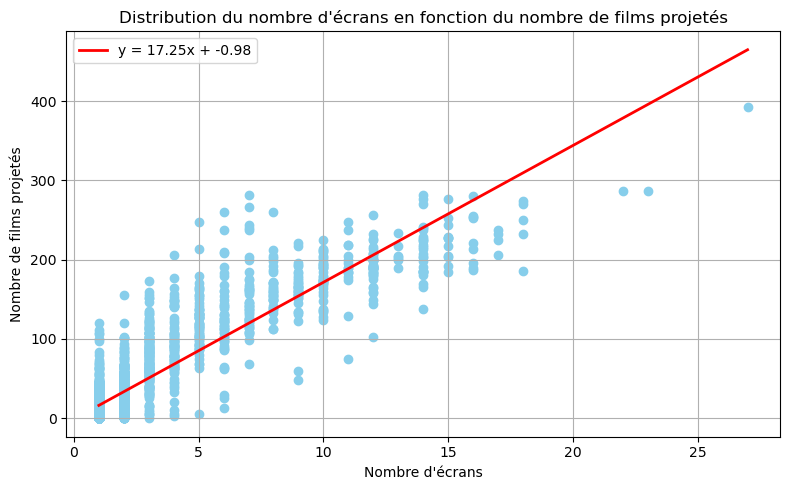

In [13]:
# Nuage de points
plt.figure(figsize=(8, 5))
plt.scatter(data2019["écrans"], data2019["nombre de films en semaine 1"], color='skyblue')

# Droite de régression
a, b = np.polyfit(data2019["écrans"], data2019["nombre de films en semaine 1"], 1)
x_vals = np.linspace(data2019["écrans"].min(), data2019["écrans"].max(), 100)
y_vals = a * x_vals + b
plt.plot(x_vals, y_vals, color='red', linewidth=2, label=f'y = {a:.2f}x + {b:.2f}')

# Mise en forme du graphique
plt.title("Distribution du nombre d'écrans en fonction du nombre de films projetés")
plt.xlabel("Nombre d'écrans")
plt.ylabel("Nombre de films projetés")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**On constate ici un lien entre le nombre d'écrans et le nombre de films projetés**

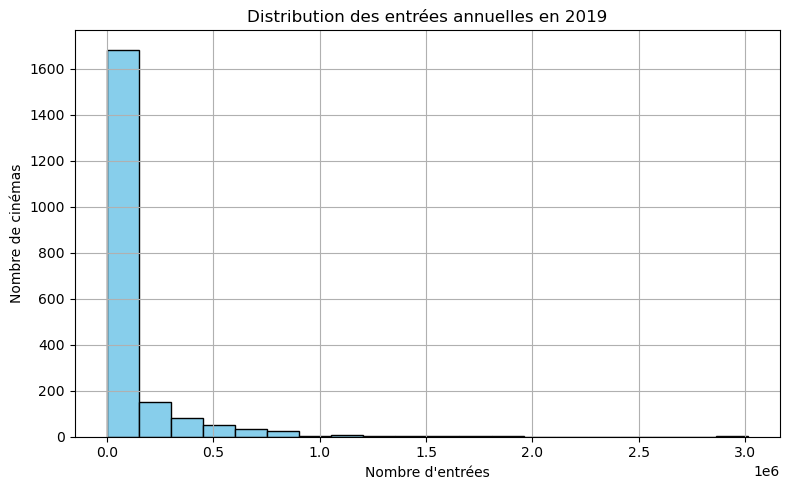

In [14]:
# Nettoyage : on enlève les espaces et on convertit en float
data2019["entrées"] = data2019["entrées"].str.replace(" ", "").astype(float)

# Refaire le graphique proprement
plt.figure(figsize=(8, 5))
plt.hist(data2019["entrées"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution des entrées annuelles en 2019")
plt.xlabel("Nombre d'entrées")
plt.ylabel("Nombre de cinémas")
plt.grid(True)
plt.tight_layout()
plt.show()


#### 2.2 - Année <u>2020</u>

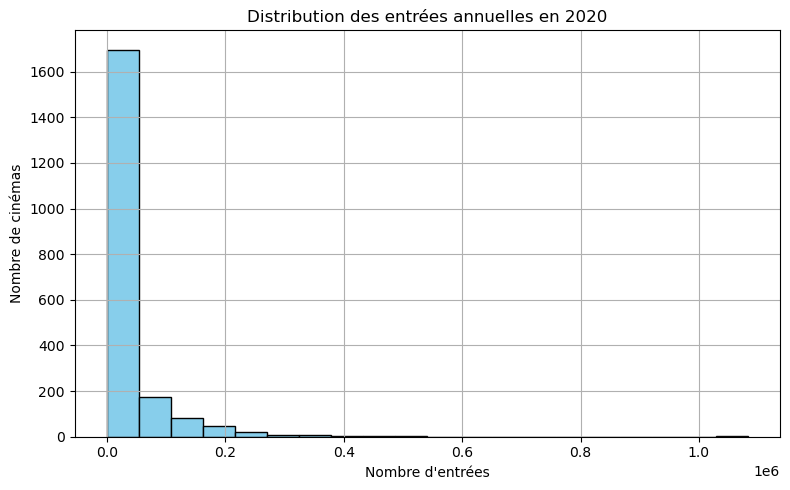

In [15]:
# Nettoyage : on enlève les espaces et on convertit en float
data2020["entrées"] = data2020["entrées"].str.replace(" ", "").astype(float)

# Refaire le graphique proprement
plt.figure(figsize=(8, 5))
plt.hist(data2020["entrées"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution des entrées annuelles en 2020")
plt.xlabel("Nombre d'entrées")
plt.ylabel("Nombre de cinémas")
plt.grid(True)
plt.tight_layout()
plt.show()

**Ces deux graphiques illustrent la distribution des entrées annuelles en 2019 et en 2022**  
<u>On constate ici une diminution des enrées de 2019 par apport à 2020. On peut le justifier par la période Covid-19</u>

#### 2.3 - Années <u>2018, 2019, 2020, 2021</u>

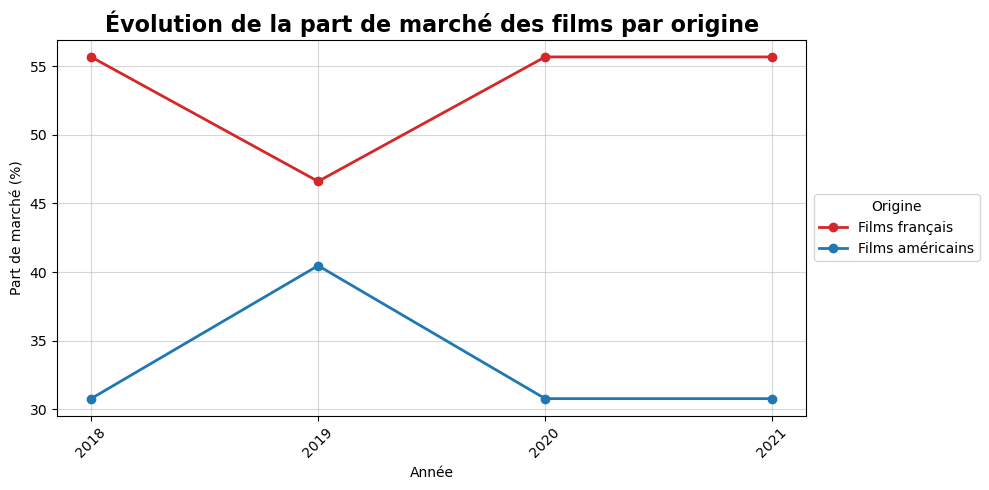

In [16]:
# Concaténation des données
df_total = pd.concat([data2018, data2019, data2020, data2021], ignore_index=True)

# Copie de sécurité
df_pdm = df_total.copy()

# Nettoyage des parts de marché
colonnes_pdm = ['PdM en entrées des films français', 'PdM en entrées des films américains']
for col in colonnes_pdm:
    df_pdm[col] = df_pdm[col].astype(str)
    df_pdm[col] = df_pdm[col].replace('#DIV/0!', 'NaN')
    df_pdm[col] = df_pdm[col].str.replace(',', '.').str.strip()
    df_pdm[col] = pd.to_numeric(df_pdm[col], errors='coerce')

# Moyennes par année
pdm_par_année = df_pdm.groupby('année')[colonnes_pdm].mean().reset_index()

# Conversion et tri des années
pdm_par_année['année'] = pd.to_numeric(pdm_par_année['année'], errors='coerce')
pdm_par_année = pdm_par_année.sort_values(by='année')

# Arrondi pour affichage et export
pdm_par_année = pdm_par_année.round(2)

# Calcul des écarts avec l'année précédente
pdm_par_année['Écart FR'] = pdm_par_année['PdM en entrées des films français'].diff().fillna(0).round(2)
pdm_par_année['Écart US'] = pdm_par_année['PdM en entrées des films américains'].diff().fillna(0).round(2)

# Tracé des parts de marché
plt.figure(figsize=(10, 5))
plt.plot(pdm_par_année['année'], pdm_par_année['PdM en entrées des films français'],
         marker='o', linewidth=2, color='#d62728', label='Films français')  # Rouge
plt.plot(pdm_par_année['année'], pdm_par_année['PdM en entrées des films américains'],
         marker='o', linewidth=2, color='#1f77b4', label='Films américains')  # Bleu

plt.title('Évolution de la part de marché des films par origine', fontsize=16, fontweight='bold')
plt.xlabel('Année')
plt.ylabel('Part de marché (%)')
plt.xticks(ticks=sorted(pdm_par_année['année'].unique()), rotation=45)
plt.yticks()
plt.grid(alpha=0.5)

plt.legend(title="Origine", loc='center left', bbox_to_anchor=(1.01, 0.5), borderaxespad=0)
plt.tight_layout()
plt.show()


**Ce graphique-ci montre l'évolution de la part de marché des films selon l'origine du film (qu'il soit Français ou Américain)**  
<u>On remarque que la part de marché des films Américains avait augmenté en 2019 et celle des films Français avait diminué, mais s'est stabilisée pour revenir à la part initialle en 2020 et 2021</u>

## <u><b>Conclusion du notebook</u></b>

Ce notebook a permis de verbaliser le traitement et l’analyse de données cinématographiques.  
À travers une démarche progressive, nous avons **importé, nettoyé, transformé et analysé les jeux de données** à l’aide de bibliothèques Python comme `pandas`, `mathplotlib` et notre `module cinéma`. Les <u>indicateurs statistiques</u> calculés (moyennes, extrêmes, répartitions géographiques) ont mis en lumière des tendances pertinentes sur la **fréquentation des cinémas, le matériel ou encore les films diffusés**. 
La visualisation a joué un rôle central pour rendre les résultats lisibles et interprétables. 
Ce travail nous a permis de dégager des constats clairs sur les dynamiques de fréquentation et les caractéristiques du parc cinématographique en France sur plusieurs années.

## <u><b> Conclusion générale de la SAE</u></b>

Ce projet de SAE nous a permis de mobiliser un ensemble de compétences en **traitement de données, en analyse statistique et en visualisation**.  
Il nous a appris à **travailler ensemble** sur une étude structurée, de la récupération de données brutes à la production de résultats. L’usage d’un module Python personnel a renforcé notre autonomie technique. Nous avons pu mettre en évidence des évolutions multi-annuelles sur la fréquentation des salles de cinéma, illustrées par des indicateurs fiables et des représentations graphiques claires.
Cette SAE constitue ainsi une base solide pour de futures analyses et travaux plus poussées.
